# Fashion-MNIST 의류 이미지 분류

## 1. 주제 및 데이터셋 선택
- Fashion-MNIST 데이터셋을 이용하여 의류 이미지를 10개의 클래스로 분류하는 딥러닝 모델을 구현한다.

## 2. 데이터셋 소개

Fashion-MNIST는 28×28 크기의 흑백 의류 이미지로 구성된 데이터셋이다.

- 학습 데이터: 60,000개
- 테스트 데이터: 10,000개
- 이미지 크기: 28×28
- 클래스 수: 10개

| 레이블 | 클래스 |
|---:|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

## 3. 라이브러리 불러오기 및 환경설정

In [15]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

print("PyTorch 버전:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("사용 장치:", device)

PyTorch 버전: 2.13.0+cpu
사용 장치: cpu


In [5]:
plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False

SEED = 42

random.seed(SEED)                   # python random 시드 고정
np.random.seed(SEED)                # Numpy 시드 고정
torch.manual_seed(SEED)             # pytorch CPU 시드 고정
torch.cuda.manual_seed_all(SEED)    # pytorch GPU 시드 고정


## 4. 데이터 불러오기

In [ ]:
# 이미지를 Tensor로 변환하고 정규화
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))        # Normalize((0.5,), (0.5,))는 픽셀값을 기존 [0, 1] 범위에서 대략 [-1, 1] 범위로 변환
])

# 학습 데이터 다운로드
full_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# 테스트 데이터 다운로드
test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("전체 학습 데이터:", len(full_train_dataset))
print("테스트 데이터:", len(test_dataset))
print("이미지 크기:", full_train_dataset[0][0].shape)

100%|██████████| 26.4M/26.4M [00:07<00:00, 3.56MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 104kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.86MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.82MB/s]


전체 학습 데이터: 60000
테스트 데이터: 10000
이미지 크기: torch.Size([1, 28, 28])


In [13]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

sample_image, sample_label = full_train_dataset[0]

print("전체 학습 이미지 개수:", len(full_train_dataset))
print("테스트 이미지 개수:", len(test_dataset))
print("클래스 개수:", len(class_names))
print("클래스 목록:", class_names)

print("\n[샘플 데이터 정보]")
print("이미지 shape:", sample_image.shape)
print("이미지 dtype:", sample_image.dtype)
print("레이블 shape:", torch.tensor(sample_label).shape)
print("레이블 dtype:", torch.tensor(sample_label).dtype)
print("레이블 값:", sample_label)
print("클래스 이름:", class_names[sample_label])

print("\n[픽셀값 범위]")
print("최솟값:", sample_image.min().item())
print("최댓값:", sample_image.max().item())



전체 학습 이미지 개수: 60000
테스트 이미지 개수: 10000
클래스 개수: 10
클래스 목록: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

[샘플 데이터 정보]
이미지 shape: torch.Size([1, 28, 28])
이미지 dtype: torch.float32
레이블 shape: torch.Size([])
레이블 dtype: torch.int64
레이블 값: 9
클래스 이름: Ankle boot

[픽셀값 범위]
최솟값: -1.0
최댓값: 1.0


###  데이터 전처리

Fashion-MNIST 이미지는 크기가 모두 28×28이고 흑백 단일 채널로 구성되어 있으므로 별도의 이미지 크기 조정은 수행하지 않았다.

다음과 같은 전처리를 적용하였다.

1. `ToTensor()`를 사용하여 이미지를 PyTorch Tensor로 변환하였다.
2. 이미지의 픽셀값을 `[0, 1]` 범위로 변환하였다.
3. 평균과 표준편차를 각각 0.5로 설정하여 픽셀값을 약 `[-1, 1]` 범위로 정규화하였다.
4. 원본 학습 데이터 60,000개를 학습 데이터 54,000개와 검증 데이터 6,000개로 분할하였다.
5. 테스트 데이터 10,000개는 최종 성능 평가에만 사용한다.

데이터의 용도는 다음과 같다.

- **Train set:** 모델의 가중치 학습
- **Validation set:** 학습 과정의 성능 확인과 모델 선택
- **Test set:** 최종 모델의 일반화 성능 평가

학습 데이터의 순서는 매 에포크마다 섞이도록 `shuffle=True`를 적용하였다. 검증 및 테스트 데이터는 모델 학습에 사용되지 않으므로 `shuffle=False`를 적용하였다.

## 5. 학습/ 검증 데이터 분리

In [7]:
train_size = 54000
val_size = 6000

# 시드를 고정한 생성기를 사용하여 매번 동일하게 분할
generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

print("학습 데이터:", len(train_dataset))
print("검증 데이터:", len(val_dataset))
print("테스트 데이터:", len(test_dataset))

학습 데이터: 54000
검증 데이터: 6000
테스트 데이터: 10000


In [23]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 첫 번째 미니배치 확인
images, labels = next(iter(train_loader))

print("배치 이미지 크기:", images.shape)
print("배치 레이블 크기:", labels.shape)
print("미니배치 개수:", len(train_loader))

배치 이미지 크기: torch.Size([128, 1, 28, 28])
배치 레이블 크기: torch.Size([128])
미니배치 개수: 422


### 전처리 전후 비교 확인

In [28]:
# Fashion-MNIST 원본 이미지는 PIL 이미지 형태로 저장되어 있음
raw_image, raw_label = full_train_dataset.data[0], full_train_dataset.targets[0]

# 현재 Dataset에서 전처리된 이미지
normalized_image, normalized_label = full_train_dataset[0]

print("[전처리 전]")
print("shape:", raw_image.shape)
print("dtype:", raw_image.dtype)
print("픽셀 범위:", raw_image.min().item(), "~", raw_image.max().item())

print("\n[전처리 후]")
print("shape:", normalized_image.shape)
print("dtype:", normalized_image.dtype)
print(
    "픽셀 범위:",
    normalized_image.min().item(),
    "~",
    normalized_image.max().item()
)

[전처리 전]
shape: torch.Size([28, 28])
dtype: torch.uint8
픽셀 범위: 0 ~ 255

[전처리 후]
shape: torch.Size([1, 28, 28])
dtype: torch.float32
픽셀 범위: -1.0 ~ 1.0


## 6. 데이터 분할별 클래스 분포 확인

In [16]:
# 클래스 번호를 문자열로 생성
class_names = [str(i) for i in range(10)]

# random_split으로 생성된 Subset에서 원본 데이터의 인덱스 추출
train_indices = train_dataset.indices
valid_indices = val_dataset.indices

# 원본 Fashion-MNIST 데이터에서 각 분할에 해당하는 레이블 추출
train_labels = full_train_dataset.targets[train_indices].numpy()
valid_labels = full_train_dataset.targets[valid_indices].numpy()
test_labels = test_dataset.targets.numpy()

# 학습·검증·테스트 데이터의 클래스별 개수를 하나의 표로 구성
label_df = pd.DataFrame({
    "train": pd.Series(train_labels).value_counts().sort_index(),
    "valid": pd.Series(valid_labels).value_counts().sort_index(),
    "test": pd.Series(test_labels).value_counts().sort_index()
})

# 인덱스와 열 이름 설정
label_df.index = class_names
label_df.index.name = "class"

label_df

,train,valid,test
class,,,
0,5342,658,1000
1,5389,611,1000
2,5388,612,1000
3,5438,562,1000
4,5393,607,1000
5,5387,613,1000
6,5400,600,1000
7,5463,537,1000
8,5402,598,1000


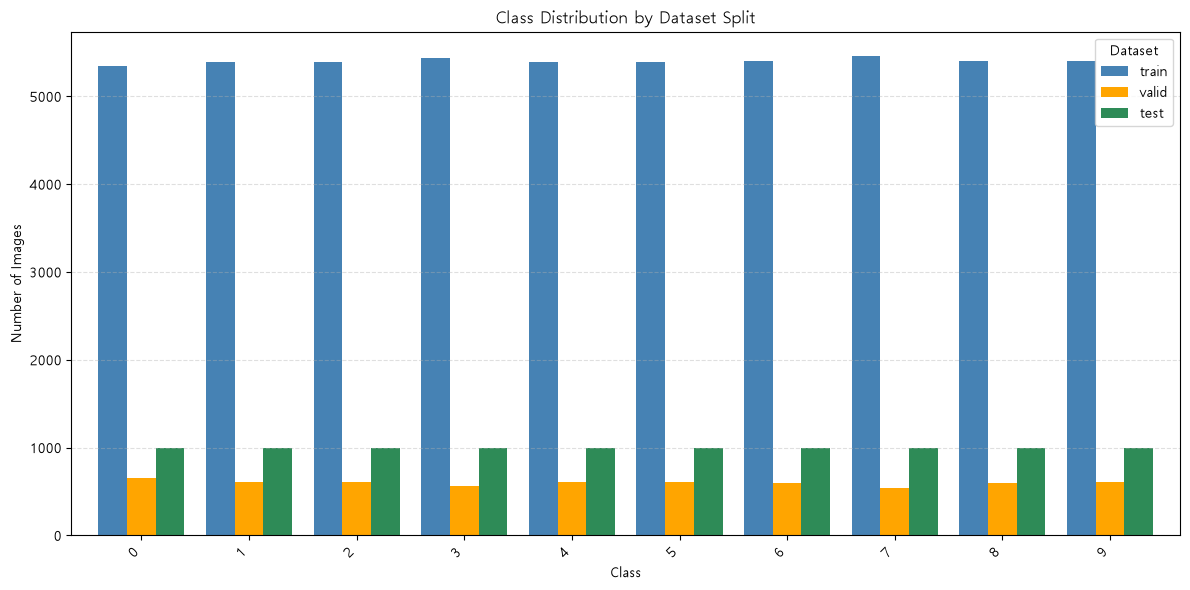

In [17]:
ax = label_df.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
    color=["steelblue", "orange", "seagreen"]
)

plt.title("Class Distribution by Dataset Split")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Dataset")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 7.이미지 데이터
- 클래스별 이미지 샘플 출력
- 이미지 크기 및 채널 확인
- 밝기, 색상, 형태 차이 확인
- 잘못 분류되었거나 품질이 낮은 이미지 확인

클래스별 이미지 샘플 출력

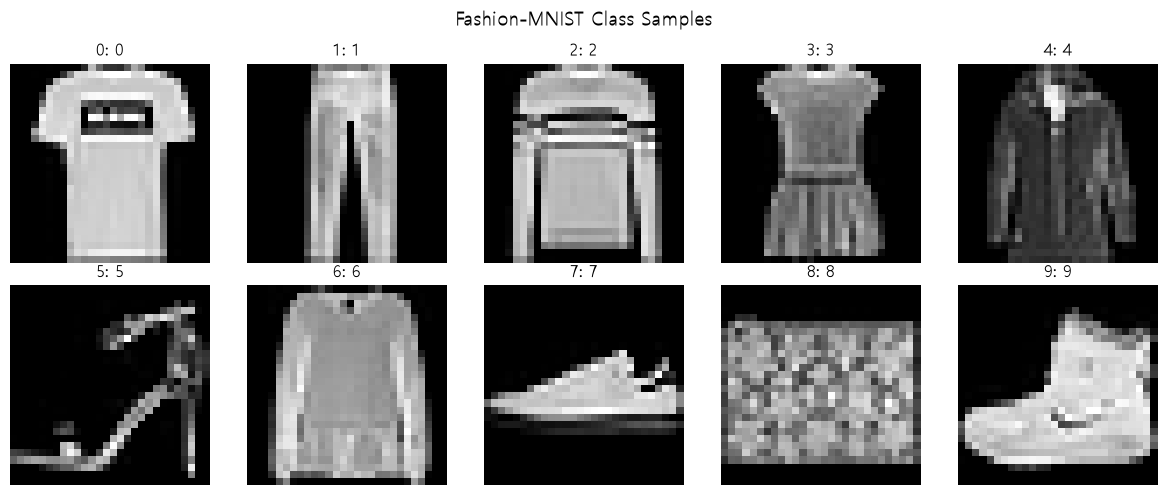

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for class_idx in range(10):
    # 현재 클래스에 해당하는 첫 번째 이미지의 위치
    image_idx = torch.where(
        full_train_dataset.targets == class_idx
    )[0][0].item()

    image, label = full_train_dataset[image_idx]

    # 정규화된 [-1, 1] 값을 다시 [0, 1] 범위로 복원
    image = image * 0.5 + 0.5

    ax = axes.flat[class_idx]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"{class_idx}: {class_names[class_idx]}")
    ax.axis("off")

plt.suptitle("Fashion-MNIST Class Samples", fontsize=14)
plt.tight_layout()
plt.show()

이미지 크기 및 채널 확인

In [24]:
# 앞에서 확인한 첫 번째 학습 배치 사용
images, labels = next(iter(train_loader))

# 정규화된 [-1, 1] 범위를 원래의 [0, 1] 범위로 복원
restored_images = images * 0.5 + 0.5

print("배치 shape:", restored_images.shape)
print("픽셀 최솟값:", restored_images.min().item())
print("픽셀 최댓값:", restored_images.max().item())
print("픽셀 평균:", restored_images.mean().item())
print("픽셀 표준편차:", restored_images.std().item())

배치 shape: torch.Size([128, 1, 28, 28])
픽셀 최솟값: 0.0
픽셀 최댓값: 1.0
픽셀 평균: 0.2944208085536957
픽셀 표준편차: 0.3711205720901489


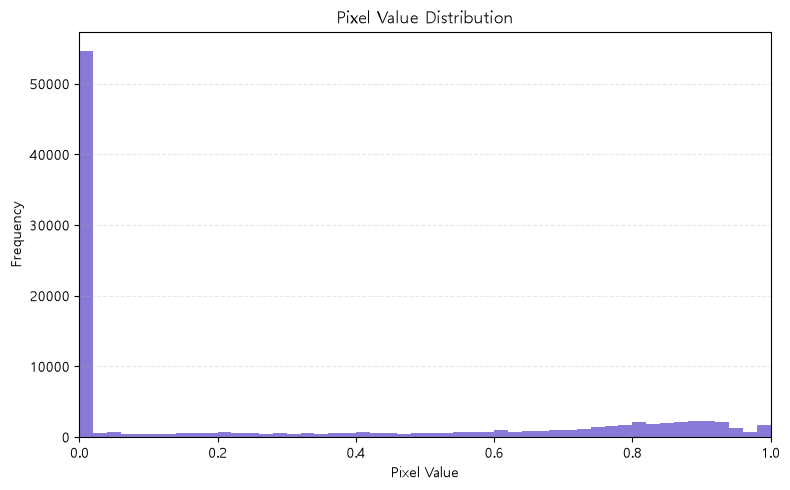

In [25]:
pixel_values = restored_images.flatten().numpy()

plt.figure(figsize=(8, 5))
plt.hist(
    pixel_values,
    bins=50,
    color="slateblue",
    alpha=0.8
)

plt.title("Pixel Value Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.xlim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Fashion-MNIST는 검은 배경이 넓은 이미지이므로, 일반적으로 0에 가까운 픽셀이 매우 많이 나타남을 확인

이미지별 평균 밝기 확인

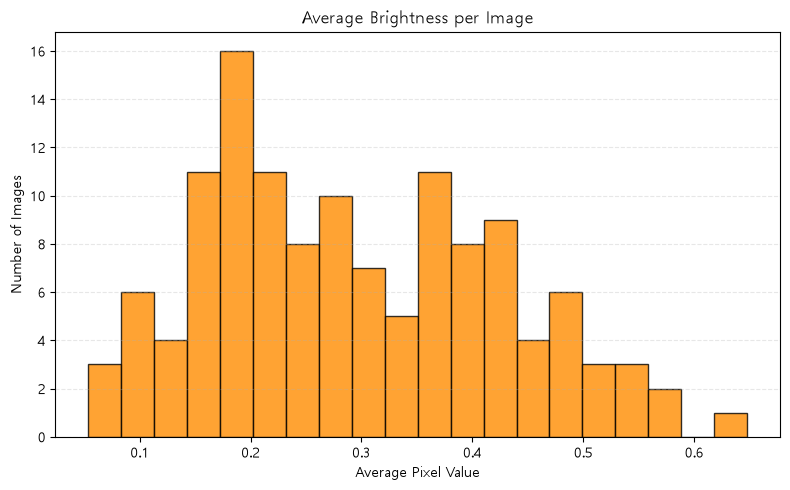

In [26]:
# 각 이미지의 평균 픽셀값 계산
image_brightness = restored_images.mean(dim=(1, 2, 3)).numpy()

plt.figure(figsize=(8, 5))
plt.hist(
    image_brightness,
    bins=20,
    color="darkorange",
    edgecolor="black",
    alpha=0.8
)

plt.title("Average Brightness per Image")
plt.xlabel("Average Pixel Value")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

각 이미지의 평균 밝기가 완전히 같지 않은 것은 의류가 차지하는 면적, 모양, 명암이 서로 다르기 때문.   
이 차이는 CNN이 의류의 형태를 학습할 때 활용할 수 있는 이미지 특성 중 하나이다.

In [29]:
train_images, train_labels = next(iter(train_loader))
valid_images, valid_labels = next(iter(val_loader))
test_images, test_labels = next(iter(test_loader))

print("[Train batch]")
print("images:", train_images.shape)
print("labels:", train_labels.shape)
print("image dtype:", train_images.dtype)
print("label dtype:", train_labels.dtype)

print("\n[Validation batch]")
print("images:", valid_images.shape)
print("labels:", valid_labels.shape)

print("\n[Test batch]")
print("images:", test_images.shape)
print("labels:", test_labels.shape)

[Train batch]
images: torch.Size([128, 1, 28, 28])
labels: torch.Size([128])
image dtype: torch.float32
label dtype: torch.int64

[Validation batch]
images: torch.Size([128, 1, 28, 28])
labels: torch.Size([128])

[Test batch]
images: torch.Size([128, 1, 28, 28])
labels: torch.Size([128])


## 6. CNN 모델 구조 설계

Fashion-MNIST는 이미지 데이터이므로 공간적 특징을 효과적으로 추출할 수 있는 CNN(Convolutional Neural Network)을 사용한다.

모델은 다음 구조로 설계하였다.

1. 첫 번째 합성곱 층: 채널을 1개에서 32개로 변환
2. ReLU 활성화 함수
3. Max Pooling: 이미지 크기를 28×28에서 14×14로 축소
4. 두 번째 합성곱 층: 채널을 32개에서 64개로 변환
5. ReLU 활성화 함수
6. Max Pooling: 이미지 크기를 14×14에서 7×7로 축소
7. Flatten: 특징 맵을 일차원 벡터로 변환
8. 완전연결층과 Dropout 적용
9. 10개 클래스에 대응하는 출력값 생성

Fashion-MNIST는 10개의 클래스를 분류하는 다중 분류 문제이므로 출력층의 노드 수를 10개로 설정한다.

손실함수로 `CrossEntropyLoss`를 사용할 예정이므로 출력층에는 Softmax를 직접 적용하지 않는다.

In [31]:
class FashionCNN(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super().__init__()

        # 이미지에서 특징을 추출하는 부분
        self.features = nn.Sequential(
            # [배치, 1, 28, 28] -> [배치, 16, 28, 28]
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.SiLU(),

            # [배치, 16, 28, 28] -> [배치, 16, 14, 14]
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(p=dropout_rate),

            # [배치, 16, 14, 14] -> [배치, 32, 14, 14]
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.SiLU(),

            # [배치, 32, 14, 14] -> [배치, 32, 7, 7]
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(p=dropout_rate)
        )

        # 추출된 특징을 이용하여 최종 클래스를 분류하는 부분
        self.classifier = nn.Sequential(
            # [배치, 32, 7, 7] -> [배치, 1568]
            nn.Flatten(),

            nn.Linear(32 * 7 * 7, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(p=0.4),

            # Fashion-MNIST 의류 10개 클래스에 대한 로짓 출력
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [32]:
DROPOUT_RATE = 0.2

model = FashionCNN(dropout_rate=DROPOUT_RATE)

sample_input = train_images[:4]

model.eval()

with torch.no_grad():
    feature_output = model.features(sample_input)
    final_output = model(sample_input)

print(model)
print("\n입력 shape:", sample_input.shape)
print("특징 맵 shape:", feature_output.shape)
print("최종 출력 shape:", final_output.shape)

FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.2, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): SiLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): SiLU()
    (4): Dropout(p=0.4, inplace=False)
    (5): Linear(in_features=128, out_f

### 7. 학습 환경과 하이퍼파라미터 설정

In [36]:
total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"전체 파라미터 수: {total_params:,}")
print(f"학습 가능 파라미터 수: {trainable_params:,}")

전체 파라미터 수: 207,274
학습 가능 파라미터 수: 207,274


In [37]:
# 하이퍼파라미터
LEARNING_RATE = 0.001
EPOCHS = 15

# 모델을 연산 장치로 이동
model = FashionCNN(dropout_rate=0.2).to(device)

# 다중 분류 손실함수
criterion = nn.CrossEntropyLoss()

# 옵티마이저
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("사용 장치:", device)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)
print("Optimizer:", optimizer.__class__.__name__)
print("Loss function:", criterion.__class__.__name__)

사용 장치: cpu
Batch size: 128
Learning rate: 0.001
Epochs: 15
Optimizer: Adam
Loss function: CrossEntropyLoss


### 학습 환경과 하이퍼파라미터 정리

모델 학습에 사용한 주요 설정은 다음과 같다.

| 항목 | 설정값 |
|---|---:|
| 모델 | CNN |
| 활성화 함수 | SiLU |
| Batch size | 128 |
| Epoch | 15 |
| Learning rate | 0.001 |
| Optimizer | Adam |
| Loss function | CrossEntropyLoss |
| 특징 추출 Dropout | 0.2 |
| 분류기 Dropout | 0.4 |


본 문제는 10개의 의류 클래스를 예측하는 다중 분류 문제이므로 `CrossEntropyLoss`를 사용하였다. 옵티마이저는 학습률을 각 파라미터에 맞게 조절하는 Adam을 사용하였다.

### 8. 모델 학습

학습 함수

In [39]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    # BatchNorm과 Dropout을 학습 모드로 설정
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in data_loader:
        # 입력과 정답을 연산 장치로 이동
        images = images.to(device)
        labels = labels.to(device)

        # 이전 미니배치에서 계산된 기울기 초기화
        optimizer.zero_grad()

        # 순전파
        outputs = model(images)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 역전파
        loss.backward()

        # 모델 파라미터 업데이트
        optimizer.step()

        # 배치 손실 누적
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        # 가장 높은 로짓을 가진 클래스를 예측값으로 선택
        predictions = outputs.argmax(dim=1)

        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

검증함수

In [40]:
def evaluate(model, data_loader, criterion, device):
    # BatchNorm과 Dropout을 평가 모드로 설정
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # 기울기 계산 비활성화
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            # 순전파
            outputs = model(images)

            # 손실 계산
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size

            predictions = outputs.argmax(dim=1)

            correct_predictions += (
                predictions == labels
            ).sum().item()

            total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

In [41]:
import copy
import time

history = {
    "train_loss": [],
    "train_accuracy": [],
    "valid_loss": [],
    "valid_accuracy": []
}

best_valid_accuracy = 0.0
best_epoch = 0
best_model_state = None

start_time = time.time()

for epoch in range(EPOCHS):
    # 학습
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    # 검증
    valid_loss, valid_accuracy = evaluate(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=device
    )

    # 학습 기록 저장
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["valid_loss"].append(valid_loss)
    history["valid_accuracy"].append(valid_accuracy)

    # 검증 정확도가 가장 높은 모델의 가중치 보관
    if valid_accuracy > best_valid_accuracy:
        best_valid_accuracy = valid_accuracy
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch [{epoch + 1:02d}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy * 100:.2f}% "
        f"| Valid Loss: {valid_loss:.4f} "
        f"| Valid Acc: {valid_accuracy * 100:.2f}%"
    )

elapsed_time = time.time() - start_time

print("\n학습 완료")
print(f"전체 학습 시간: {elapsed_time:.2f}초")
print(f"최고 검증 정확도: {best_valid_accuracy * 100:.2f}%")
print(f"최고 성능 에포크: {best_epoch}")

Epoch [01/15] | Train Loss: 0.5123 | Train Acc: 82.89% | Valid Loss: 0.3280 | Valid Acc: 88.03%
Epoch [02/15] | Train Loss: 0.3498 | Train Acc: 87.32% | Valid Loss: 0.2855 | Valid Acc: 89.77%
Epoch [03/15] | Train Loss: 0.3097 | Train Acc: 88.73% | Valid Loss: 0.2704 | Valid Acc: 89.93%
Epoch [04/15] | Train Loss: 0.2899 | Train Acc: 89.46% | Valid Loss: 0.2597 | Valid Acc: 90.63%
Epoch [05/15] | Train Loss: 0.2736 | Train Acc: 90.05% | Valid Loss: 0.2482 | Valid Acc: 91.07%
Epoch [06/15] | Train Loss: 0.2629 | Train Acc: 90.26% | Valid Loss: 0.2448 | Valid Acc: 90.95%
Epoch [07/15] | Train Loss: 0.2524 | Train Acc: 90.74% | Valid Loss: 0.2362 | Valid Acc: 90.97%
Epoch [08/15] | Train Loss: 0.2429 | Train Acc: 90.96% | Valid Loss: 0.2422 | Valid Acc: 91.17%
Epoch [09/15] | Train Loss: 0.2364 | Train Acc: 91.27% | Valid Loss: 0.2313 | Valid Acc: 91.45%
Epoch [10/15] | Train Loss: 0.2306 | Train Acc: 91.41% | Valid Loss: 0.2271 | Valid Acc: 91.65%
Epoch [11/15] | Train Loss: 0.2222 | Tra

최고성능 복원

In [42]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(
    f"{best_epoch}번째 에포크의 모델을 복원했습니다. "
    f"(검증 정확도: {best_valid_accuracy * 100:.2f}%)"
)

15번째 에포크의 모델을 복원했습니다. (검증 정확도: 92.15%)


### 9. 학습과정 시각화

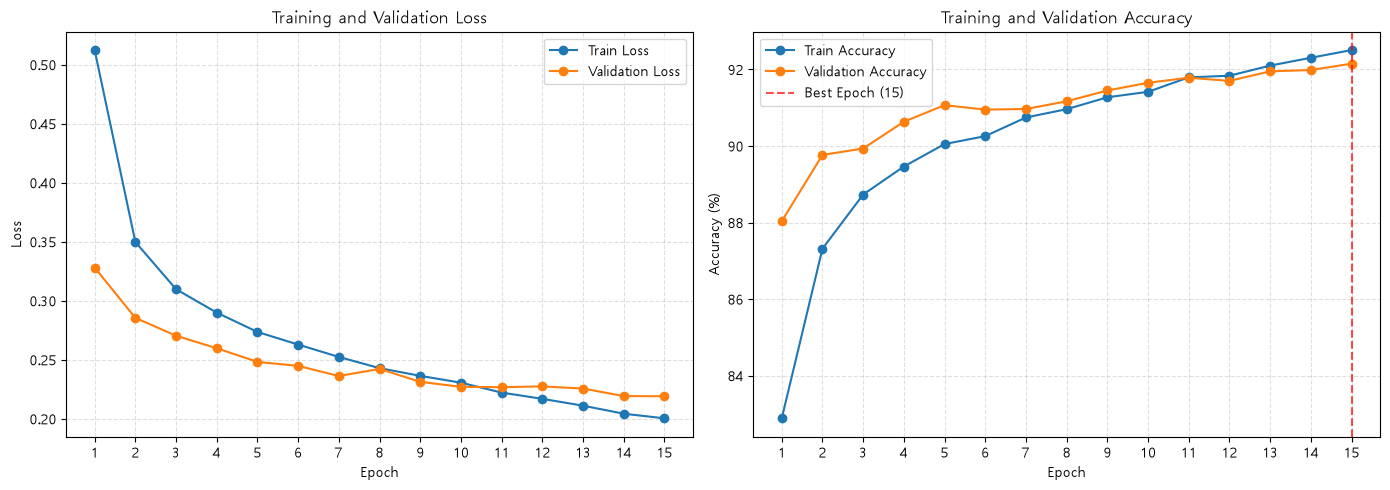

In [43]:
epochs = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 손실 그래프
axes[0].plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)
axes[0].plot(
    epochs,
    history["valid_loss"],
    marker="o",
    label="Validation Loss"
)

axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_xticks(epochs)
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend()

# 정확도 그래프
axes[1].plot(
    epochs,
    np.array(history["train_accuracy"]) * 100,
    marker="o",
    label="Train Accuracy"
)
axes[1].plot(
    epochs,
    np.array(history["valid_accuracy"]) * 100,
    marker="o",
    label="Validation Accuracy"
)

axes[1].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"Best Epoch ({best_epoch})"
)

axes[1].set_title("Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_xticks(epochs)
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()

In [44]:
best_index = best_epoch - 1

result_summary = pd.DataFrame({
    "Metric": [
        "Train Loss",
        "Validation Loss",
        "Train Accuracy",
        "Validation Accuracy",
        "Training Time (seconds)"
    ],
    "Value": [
        history["train_loss"][best_index],
        history["valid_loss"][best_index],
        history["train_accuracy"][best_index] * 100,
        history["valid_accuracy"][best_index] * 100,
        elapsed_time
    ]
})

result_summary

,Metric,Value
0,Train Loss,0.200385
1,Validation Loss,0.219051
2,Train Accuracy,92.505556
3,Validation Accuracy,92.150000
4,Training Time (seconds),3464.868701


##  학습 과정 분석

모델은 15에포크 동안 학습되었으며, 가장 높은 검증 정확도는 15번째 에포크에서 기록한 92.15%였다. 전체 학습 시간은 약 57분이었다.

학습이 진행됨에 따라 학습 손실과 검증 손실이 전반적으로 감소하고 정확도가 상승하는지 확인하였다. 특히 학습 정확도와 검증 정확도의 차이, 그리고 검증 손실의 증가 여부를 통해 과적합 가능성을 판단하였다.

최고 검증 정확도가 마지막 에포크에서 기록되었으므로 모델의 성능이 추가로 개선될 가능성은 있다. 그러나 현재 검증 정확도가 충분히 높고 학습 시간이 길기 때문에 본 실험에서는 15에포크 모델을 최종 모델로 선택하였다.

### 10. 모델평가

In [45]:
test_loss, test_accuracy = evaluate(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.2319
Test Accuracy: 91.81%


In [46]:
all_labels = []
all_predictions = []
all_probabilities = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 클래스별 로짓
        outputs = model(images)

        # 로짓을 클래스별 확률로 변환
        probabilities = torch.softmax(outputs, dim=1)

        # 확률이 가장 높은 클래스 선택
        predictions = outputs.argmax(dim=1)

        all_labels.append(labels.cpu())
        all_predictions.append(predictions.cpu())
        all_probabilities.append(probabilities.cpu())

# 배치별 결과를 하나의 Tensor로 결합
all_labels = torch.cat(all_labels).numpy()
all_predictions = torch.cat(all_predictions).numpy()
all_probabilities = torch.cat(all_probabilities).numpy()

print("정답 shape:", all_labels.shape)
print("예측값 shape:", all_predictions.shape)
print("예측 확률 shape:", all_probabilities.shape)

print("\n첫 10개 정답:")
print(all_labels[:10])

print("\n첫 10개 예측:")
print(all_predictions[:10])

정답 shape: (10000,)
예측값 shape: (10000,)
예측 확률 shape: (10000, 10)

첫 10개 정답:
[9 2 1 1 6 1 4 6 5 7]

첫 10개 예측:
[9 2 1 1 6 1 4 6 5 7]


In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f"Accuracy       : {accuracy * 100:.2f}%")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall   : {macro_recall:.4f}")
print(f"Macro F1-score : {macro_f1:.4f}")

Accuracy       : 91.81%
Macro Precision: 0.9186
Macro Recall   : 0.9181
Macro F1-score : 0.9182


In [48]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    output_dict=True,
    digits=4
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
T-shirt/top,0.883385,0.8560,0.869477,1000.0000
Trouser,0.997967,0.9820,0.989919,1000.0000
Pullover,0.877282,0.8650,0.871098,1000.0000
Dress,0.897143,0.9420,0.919024,1000.0000
Coat,0.873112,0.8670,0.870045,1000.0000
Sandal,0.993878,0.9740,0.983838,1000.0000
Shirt,0.749755,0.7640,0.756810,1000.0000
Sneaker,0.952519,0.9830,0.967520,1000.0000
Bag,0.982983,0.9820,0.982491,1000.0000
Ankle boot,0.977733,0.9660,0.971831,1000.0000


In [49]:
metric_df = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score"
    ],
    "Value": [
        test_loss,
        accuracy,
        macro_precision,
        macro_recall,
        macro_f1
    ]
})

metric_df

,Metric,Value
0,Test Loss,0.231949
1,Accuracy,0.918100
2,Macro Precision,0.918576
3,Macro Recall,0.918100
4,Macro F1-score,0.918205


혼동행렬 시각화

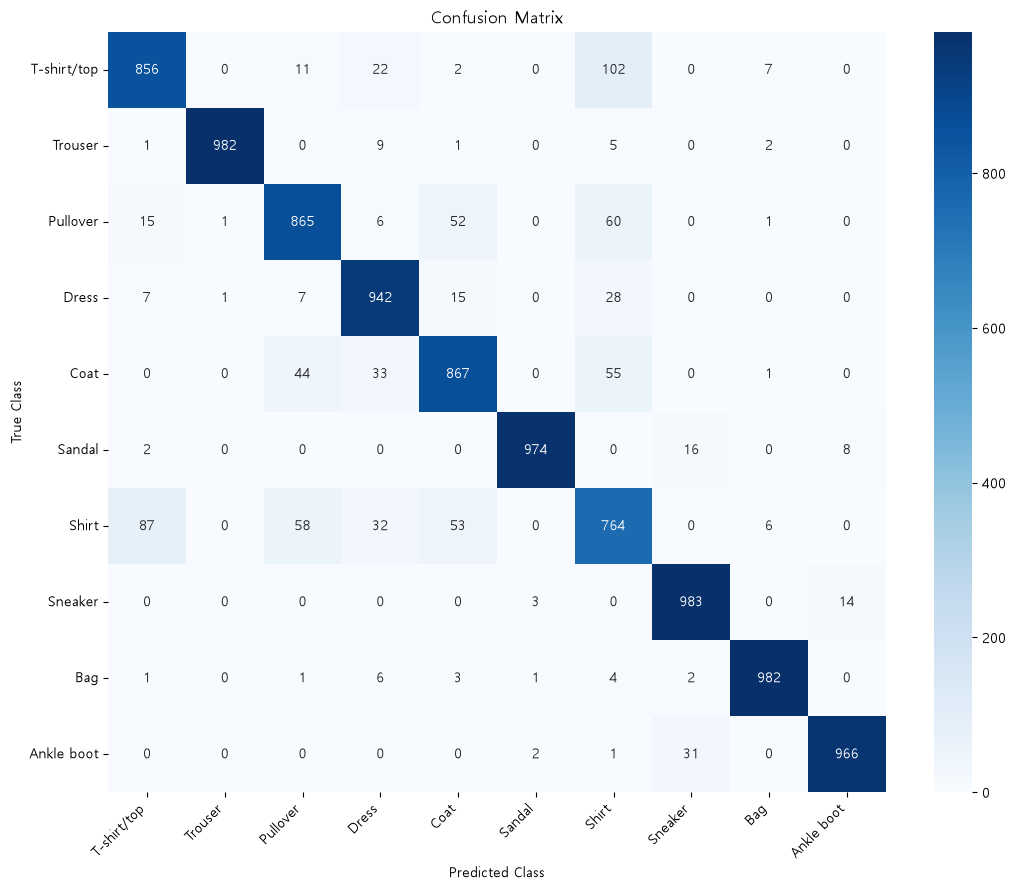

In [52]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

정규화된 혼동행렬

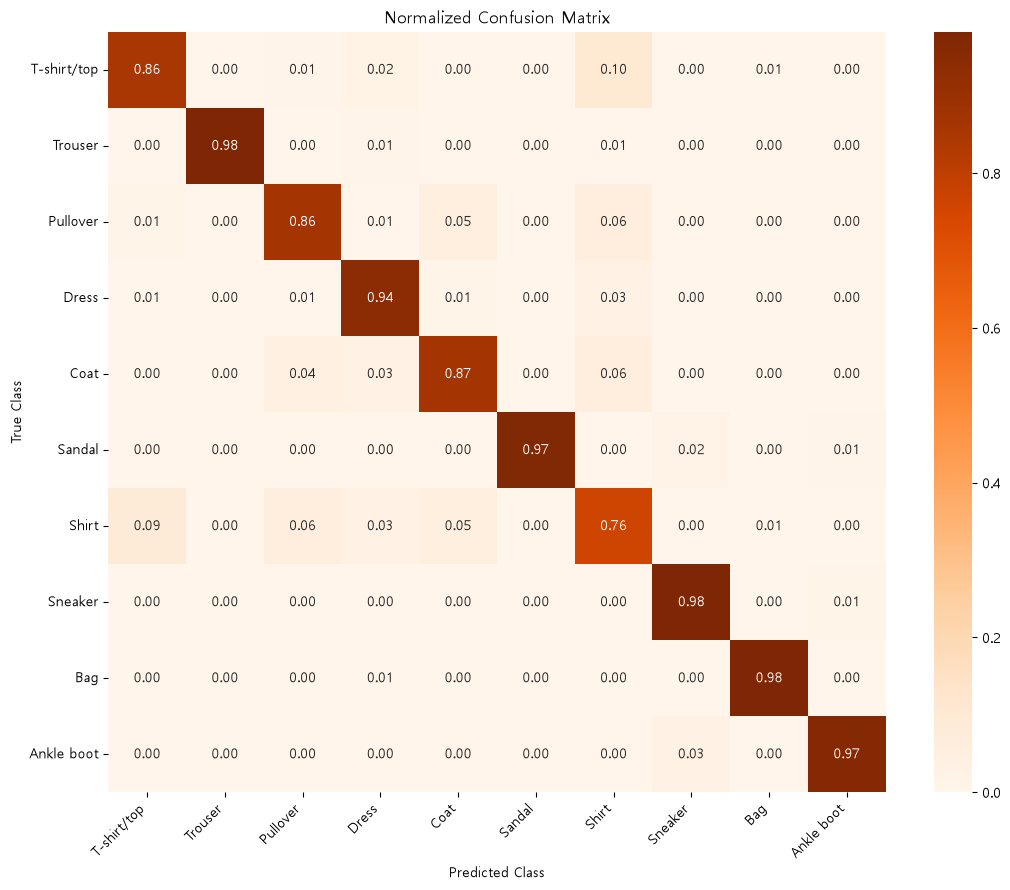

In [53]:
normalized_cm = confusion_matrix(
    all_labels,
    all_predictions,
    normalize="true"
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    normalized_cm,
    annot=True,
    fmt=".2f",
    cmap="Oranges",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

가장 많이 혼동한 클래스 조합 확인

In [54]:
confusion_pairs = []

for true_class in range(len(class_names)):
    for predicted_class in range(len(class_names)):
        if true_class != predicted_class:
            confusion_pairs.append({
                "True Class": class_names[true_class],
                "Predicted Class": class_names[predicted_class],
                "Count": cm[true_class, predicted_class]
            })

confusion_df = pd.DataFrame(confusion_pairs)

confusion_df = confusion_df.sort_values(
    by="Count",
    ascending=False
).reset_index(drop=True)

confusion_df.head(10)

,True Class,Predicted Class,Count
0,T-shirt/top,Shirt,102
1,Shirt,T-shirt/top,87
2,Pullover,Shirt,60
3,Shirt,Pullover,58
4,Coat,Shirt,55
5,Shirt,Coat,53
6,Pullover,Coat,52
7,Coat,Pullover,44
8,Coat,Dress,33
9,Shirt,Dress,32


클래스별 정확도 계산

In [57]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

class_accuracy_df = pd.DataFrame({
    "Class": class_names,
    "Correct": cm.diagonal(),
    "Total": cm.sum(axis=1),
    "Accuracy": class_accuracy,
    "Accuracy (%)": class_accuracy * 100
})

class_accuracy_df

,Class,Correct,Total,Accuracy,Accuracy (%)
0,T-shirt/top,856,1000,0.856,85.6
1,Trouser,982,1000,0.982,98.2
2,Pullover,865,1000,0.865,86.5
3,Dress,942,1000,0.942,94.2
4,Coat,867,1000,0.867,86.7
5,Sandal,974,1000,0.974,97.4
6,Shirt,764,1000,0.764,76.4
7,Sneaker,983,1000,0.983,98.3
8,Bag,982,1000,0.982,98.2
9,Ankle boot,966,1000,0.966,96.6


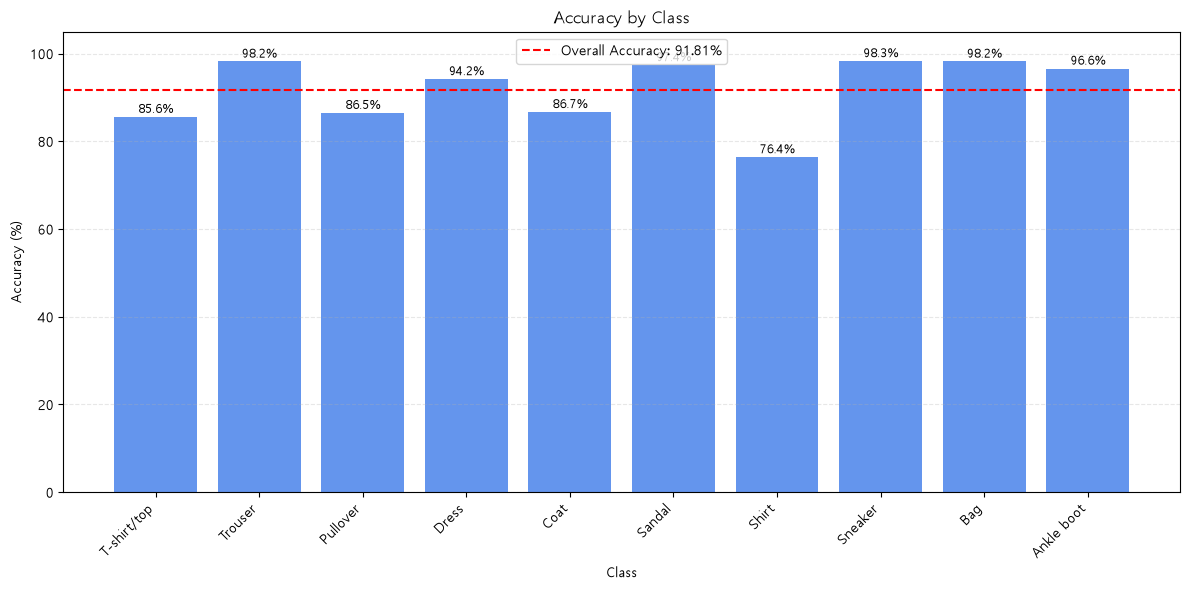

In [62]:
plt.figure(figsize=(12, 6))

bars = plt.bar(
    class_accuracy_df["Class"],
    class_accuracy_df["Accuracy (%)"],
    color="cornflowerblue"
)

# 각 막대 위에 정확도 표시
for bar, value in zip(
    bars,
    class_accuracy_df["Accuracy (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.axhline(
    accuracy * 100,
    color="red",
    linestyle="--",
    label=f"Overall Accuracy: {accuracy * 100:.2f}%"
)

plt.title("Accuracy by Class")
plt.xlabel("Class")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

최고 / 최저 성능 클래스

In [59]:
best_class_index = class_accuracy.argmax()
worst_class_index = class_accuracy.argmin()

print("[가장 높은 정확도]")
print("클래스:", class_names[best_class_index])
print(f"정확도: {class_accuracy[best_class_index] * 100:.2f}%")

print("\n[가장 낮은 정확도]")
print("클래스:", class_names[worst_class_index])
print(f"정확도: {class_accuracy[worst_class_index] * 100:.2f}%")

[가장 높은 정확도]
클래스: Sneaker
정확도: 98.30%

[가장 낮은 정확도]
클래스: Shirt
정확도: 76.40%


## 클래스별 성능 분석

클래스별 정확도를 분석한 결과, 가장 높은 정확도를 보인 클래스는 Sneaker 으로 정확도는 98.30%였다. 반면 가장 낮은 정확도를 보인 클래스는 Shirt으로 정확도는 76.40% 였다.

가방, 신발, 바지처럼 형태가 비교적 뚜렷한 클래스는 높은 정확도를 보이는 경향이 있다. 반면 Shirt, T-shirt/top, Pullover, Coat처럼 서로 형태가 유사한 상의 종류는 상대적으로 분류가 어렵다.

이는 Fashion-MNIST 이미지가 28×28 크기의 흑백 이미지이므로 의류의 재질이나 세부 디자인을 충분히 표현하기 어렵기 때문으로 해석할 수 있다.

### 11. 예측 결과 시각화 및 오류 분석

올바르게 예측한 이미지


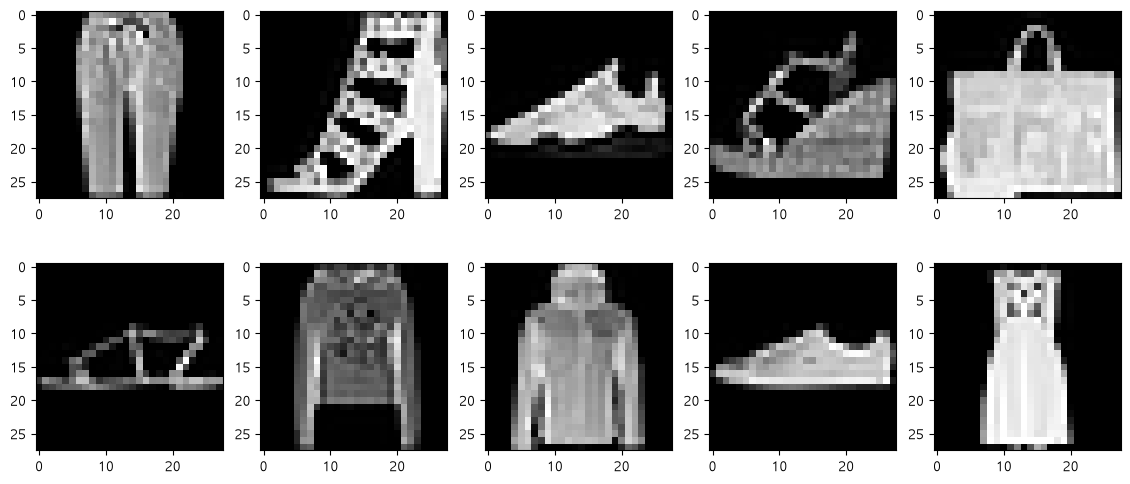

In [60]:
# 올바르게 예측한 데이터의 인덱스
correct_indices = np.where(
    all_labels == all_predictions
)[0]

# 재현 가능한 무작위 선택
rng = np.random.default_rng(SEED)

selected_correct = rng.choice(
    correct_indices,
    size=10,
    replace=False
)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for ax, idx in zip(axes.flat, selected_correct):
    image, _ = test_dataset[idx]

    # [-1, 1] 범위에서 [0, 1] 범위로 역정규화
    image = image * 0.5 + 0.5

    true_label = all_labels[idx]
    predicted_label = all_predictions[idx]
    confidence = all_probabilities[idx, predicted_label]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title

잘못 예측한 이미지

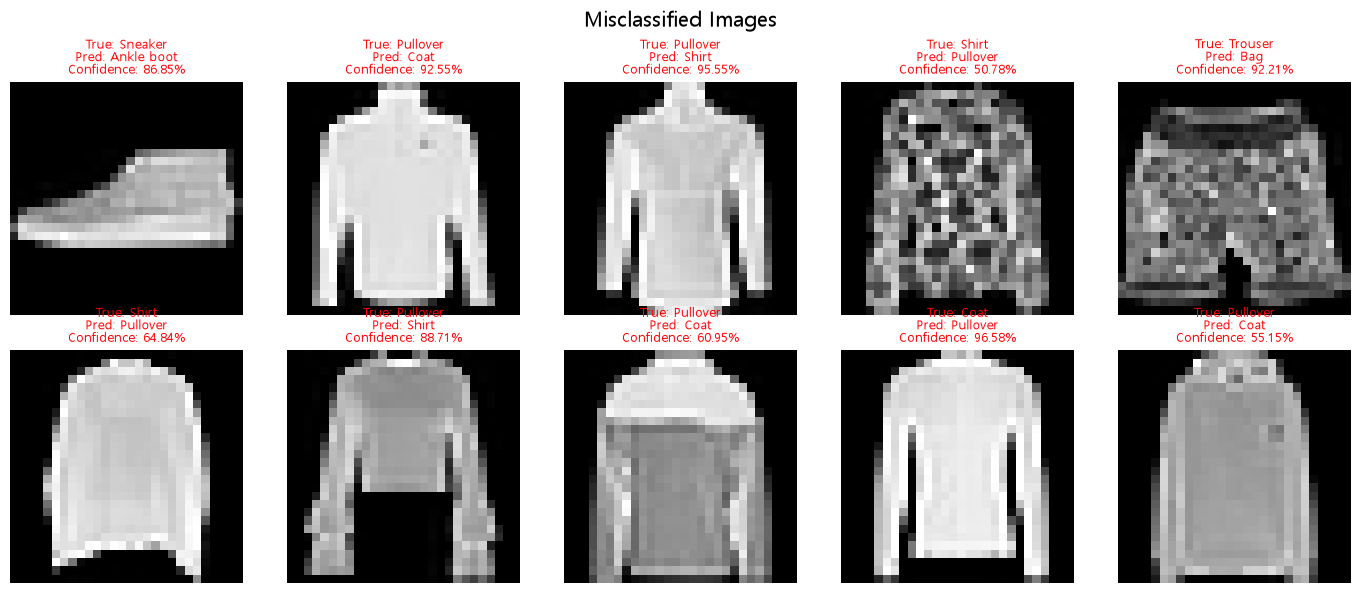

In [63]:
# 잘못 예측한 데이터의 인덱스
incorrect_indices = np.where(
    all_labels != all_predictions
)[0]

selected_incorrect = rng.choice(
    incorrect_indices,
    size=10,
    replace=False
)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for ax, idx in zip(axes.flat, selected_incorrect):
    image, _ = test_dataset[idx]
    image = image * 0.5 + 0.5

    true_label = all_labels[idx]
    predicted_label = all_predictions[idx]
    confidence = all_probabilities[idx, predicted_label]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[predicted_label]}\n"
        f"Confidence: {confidence:.2%}",
        fontsize=9,
        color="red"
    )
    ax.axis("off")

plt.suptitle("Misclassified Images", fontsize=15)
plt.tight_layout()
plt.show()

확신도가 높은 오분류 사례 확인

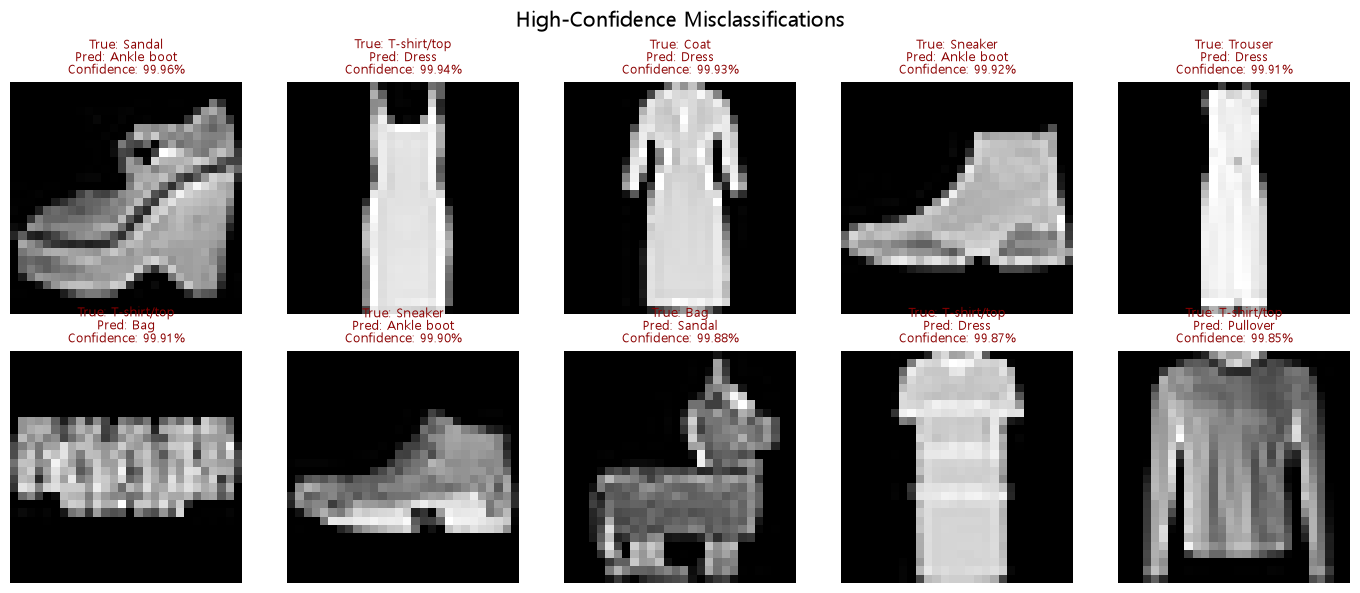

In [64]:
incorrect_confidences = np.max(
    all_probabilities[incorrect_indices],
    axis=1
)

# 오분류 데이터 중 확신도가 높은 순서
sorted_positions = np.argsort(
    incorrect_confidences
)[::-1]

high_confidence_errors = incorrect_indices[
    sorted_positions[:10]
]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for ax, idx in zip(axes.flat, high_confidence_errors):
    image, _ = test_dataset[idx]
    image = image * 0.5 + 0.5

    true_label = all_labels[idx]
    predicted_label = all_predictions[idx]
    confidence = all_probabilities[idx, predicted_label]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[predicted_label]}\n"
        f"Confidence: {confidence:.2%}",
        fontsize=9,
        color="darkred"
    )
    ax.axis("off")

plt.suptitle("High-Confidence Misclassifications", fontsize=15)
plt.tight_layout()
plt.show()

## 11. 예측 결과 및 오류 분석

올바르게 분류된 이미지에서는 의류의 전체적인 형태가 비교적 뚜렷하게 나타났다. 반면 오분류 이미지에서는 해상도가 낮거나 서로 유사한 형태를 가진 의류 사이의 혼동이 주로 발생하였다.

특히 Shirt, T-shirt/top, Pullover 및 Coat는 모두 상체에 착용하는 의류로 윤곽이 비슷하기 때문에 서로 잘못 분류되는 경우가 많았다.

일부 오분류 사례에서는 모델이 잘못된 클래스에 높은 확률을 부여하였다. 이는 모델이 예측에 대해 확신하고 있더라도 항상 올바른 것은 아니라는 점을 보여준다. 향후 데이터 증강, 모델 구조 개선 또는 학습률 조정을 통해 이러한 오류를 줄일 수 있다.